# IMPORT IMPORTANT LIBRARY AND LOADING DATASET

In [1]:

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub


/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/EV_Adoption_and_Range_Anxiety_Dataset.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/EV_Adoption_and_Range_Anxiety_Dataset.csv")

# STATISTICAL ANALYSIS

In [3]:
df.shape

(10000, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Buyer_ID                     10000 non-null  object 
 1   Age                          10000 non-null  int64  
 2   Gender                       10000 non-null  object 
 3   Annual_Income_USD            9822 non-null   float64
 4   City_Type                    10000 non-null  object 
 5   Daily_Commute_km             9819 non-null   float64
 6   Number_of_Cars_Owned         10000 non-null  int64  
 7   Current_Car_Type             10000 non-null  object 
 8   Charging_Stations_Near_Home  10000 non-null  int64  
 9   Charging_Stations_Near_Work  10000 non-null  int64  
 10  Home_Charging_Possible       10000 non-null  object 
 11  Environmental_Concern_Level  9816 non-null   float64
 12  Subsidy_Available            10000 non-null  object 
 13  Range_Anxiety_Lev

In [5]:
df.describe()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,10000.000000,9822.000000,9819.000000,10000.000000,10000.000000,10000.000000,9816.000000
mean,46.936200,85378.485848,41.105418,1.859900,5.346900,7.458200,2.982783
std,12.945968,32838.684167,23.351276,0.855421,4.049074,5.259374,1.413784
min,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,36.000000,61369.500000,23.250000,1.000000,2.000000,3.000000,2.000000
50%,47.000000,84708.000000,40.200000,2.000000,5.000000,6.000000,3.000000
75%,58.000000,107383.250000,57.000000,2.000000,8.000000,11.000000,4.000000
max,69.000000,223345.000000,135.500000,4.000000,14.000000,19.000000,5.000000


In [6]:
df.nunique()

Buyer_ID                       10000
Age                               45
Gender                             3
Annual_Income_USD               8915
City_Type                          3
Daily_Commute_km                 991
Number_of_Cars_Owned               4
Current_Car_Type                   4
Charging_Stations_Near_Home       15
Charging_Stations_Near_Work       20
Home_Charging_Possible             2
Environmental_Concern_Level        5
Subsidy_Available                  2
Range_Anxiety_Level                3
Will_Buy_EV                        2
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

## drop unnecessary column

In [8]:
df=df.drop(columns=['Buyer_ID'])

# HANDLING NULL VALUES 

In [9]:
count=df.isnull().sum()
print(count)

Age                              0
Gender                           0
Annual_Income_USD              178
City_Type                        0
Daily_Commute_km               181
Number_of_Cars_Owned             0
Current_Car_Type                 0
Charging_Stations_Near_Home      0
Charging_Stations_Near_Work      0
Home_Charging_Possible           0
Environmental_Concern_Level    184
Subsidy_Available                0
Range_Anxiety_Level              0
Will_Buy_EV                      0
dtype: int64


In [10]:
cat_col=['Annual_Income_USD','Daily_Commute_km','Environmental_Concern_Level']
for c in cat_col:
    df[c]=df[c].fillna(df[c].median())
    

# OUTLIER HANDLING

In [11]:
num_col=df.select_dtypes(include=[np.number]).columns
outlier=pd.DataFrame(False,index=df.index,columns=num_col)

for c in num_col:
    x=df[c]
    mean=x.mean(skipna=True)
    std=x.std(skipna=True)
    if std==0 or np.isnan(std):
        continue

    z=(x-mean)/std
    outlier[c]=z.abs()>3

count=outlier.sum().sort_values(ascending=False)
print(count)

Annual_Income_USD              37
Daily_Commute_km               31
Age                             0
Number_of_Cars_Owned            0
Charging_Stations_Near_Home     0
Charging_Stations_Near_Work     0
Environmental_Concern_Level     0
dtype: int64


In [12]:
outlier_col=['Annual_Income_USD','Daily_Commute_km']
for c in outlier_col:
    low=df[c].quantile(0.01)
    high=df[c].quantile(0.99)
    df[c]=df[c].clip(lower=low,upper=high)

## convert terget column to numerical format

In [13]:
df['Will_Buy_EV']=(
    df['Will_Buy_EV'].astype(str).str.strip().str.lower().map({"yes":1,"no":0}).astype(int)
)

# CORRELATION

In [14]:
corr=df.corr(numeric_only=True)
trget_corr=corr["Will_Buy_EV"].drop("Will_Buy_EV")
trget_corr

Age                            0.004303
Annual_Income_USD              0.172046
Daily_Commute_km              -0.026966
Number_of_Cars_Owned           0.000362
Charging_Stations_Near_Home   -0.002800
Charging_Stations_Near_Work    0.001259
Environmental_Concern_Level    0.362754
Name: Will_Buy_EV, dtype: float64

# EDA

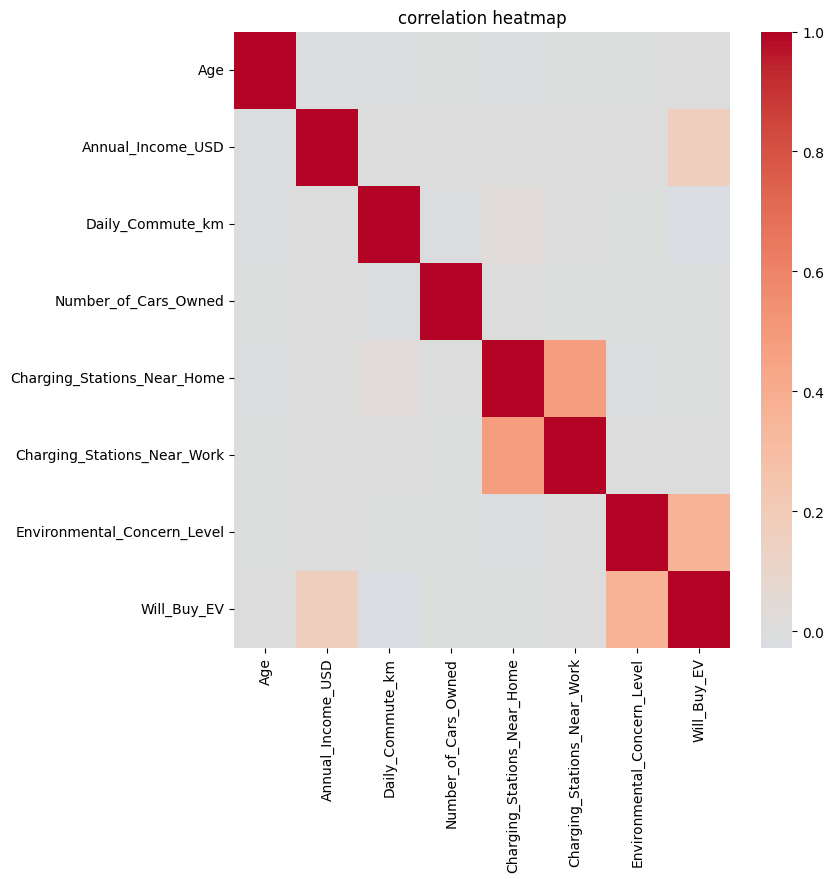

In [15]:
# correlation with terget 
corr=df.corr(numeric_only=True)
plt.figure(figsize=(8,8))
sns.heatmap(corr,cmap="coolwarm",center=0,square=False)
plt.title("correlation heatmap")
plt.show()

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          10000 non-null  int64  
 1   Gender                       10000 non-null  object 
 2   Annual_Income_USD            10000 non-null  float64
 3   City_Type                    10000 non-null  object 
 4   Daily_Commute_km             10000 non-null  float64
 5   Number_of_Cars_Owned         10000 non-null  int64  
 6   Current_Car_Type             10000 non-null  object 
 7   Charging_Stations_Near_Home  10000 non-null  int64  
 8   Charging_Stations_Near_Work  10000 non-null  int64  
 9   Home_Charging_Possible       10000 non-null  object 
 10  Environmental_Concern_Level  10000 non-null  float64
 11  Subsidy_Available            10000 non-null  object 
 12  Range_Anxiety_Level          10000 non-null  object 
 13  Will_Buy_EV      

In [17]:
df.head()

,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,56,Male,44906.0,Rural,18.1,1,Truck,1,0,Yes,4.0,Yes,Low,0
1,36,Male,88754.0,Rural,5.0,1,SUV,2,3,Yes,1.0,Yes,Low,0
2,42,Male,155958.0,Urban,32.2,2,Sedan,14,3,No,2.0,Yes,Medium,1
3,31,Male,37059.0,Rural,89.9,1,Sedan,2,1,Yes,4.0,No,Low,0
4,48,Female,48552.0,Rural,71.0,1,Sedan,2,0,Yes,3.0,Yes,Low,0


In [18]:
df.nunique()

Age                              45
Gender                            3
Annual_Income_USD              8817
City_Type                         3
Daily_Commute_km                910
Number_of_Cars_Owned              4
Current_Car_Type                  4
Charging_Stations_Near_Home      15
Charging_Stations_Near_Work      20
Home_Charging_Possible            2
Environmental_Concern_Level       5
Subsidy_Available                 2
Range_Anxiety_Level               3
Will_Buy_EV                       2
dtype: int64